In [18]:
import os, json, sys
import pandas as pd
import numpy as np
import math
import matplotlib.path as mpath
import h5py

json_file = "combined_UCE_5neuro/lasso.json" # expect all input data is in the input_dir, all output data is in the output_dir

# Open and load the JSON
with open(json_file, "r") as f:
    config = json.load(f)

input_dir = config["input_dir"]
umap_file = config["umap"]
uce_file = config["uce"]
metadata_file = config["metadata"]
output_dir = config["output_dir"]
lasso_uce_file = config["lasso_uce"]
lasso_metadata_file = config["lasso_metadata"]
level = config["level"]
image_scalef = config["image_scalef"]
coords = config["coordinates"]
x_offset, y_offset = config["offset"]
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

In [ ]:
# load umap data 
UMAP = np.load(os.path.join(input_dir, umap_file))
UMAP.shape
    
scale = math.pow(2,(level-1))
lasso = [[ (x * scale - x_offset)/image_scalef, (y * scale - y_offset)/image_scalef] for x, y in coords]

# create polygon path
polygon = mpath.Path(lasso)
# check which points are inside
mask = polygon.contains_points(UMAP)
lasso_indices = np.where(mask)[0]

# handle to uce.h5 memory efficient
out_path = os.path.join(results_dir, "lasso_uce.h5")

with h5py.File(os.path.join(input_dir, uce_file), "r") as fuce, \
     h5py.File(os.path.join(output_dir, lasso_uce_file), "w") as f_out:
    
    uce = fuce["data"]  # original dataset handle
    n_features = uce.shape[1]
    
    # Create a new dataset for the selected rows
    dset = f_out.create_dataset(
        "data", 
        shape=(len(lasso_indices), n_features), 
        dtype=uce.dtype,
        compression="gzip"  # optional but recommended
    )
    
    # Write in batches
    for i in range(0, len(lasso_indices), batch_size):
        print(i)
        batch = lasso_indices[i:i + batch_size]
        dset[i:i + len(batch), :] = uce[batch, :]

In [ ]:
meta = pd.read_csv(os.path.join(input_dir,metadata_file), sep= '\t')
lasso_meta = meta.iloc[lasso_indices,:]
lasso_meta.to_csv(os.path.join(output_dir, lasso_metadata_file), sep="\t", index=False)

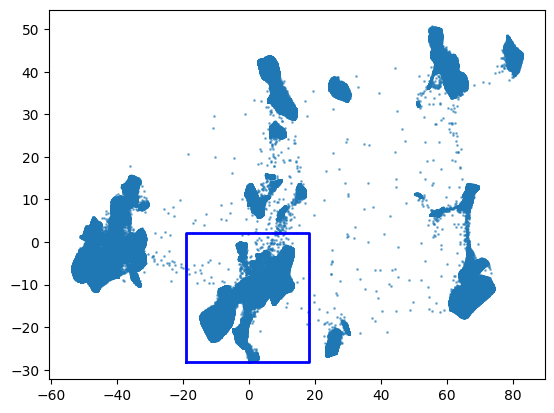

In [19]:
sys.exit()
x, y = zip(*lasso)
import matplotlib.pyplot as plt
# ploat a subset of 1M cells
subset_indices = np.random.choice(UMAP.shape[0], 1_000_000, replace=False)
plt.scatter(UMAP[subset_indices,0], UMAP[subset_indices,1], alpha =0.5, s=1)
plt.plot(x, y, 'b', linewidth=2)   # blue outline
plt.show()